Продемонстрируйте свои знания
У вас есть таблица с данными по интернет-магазинам за некоторый период. Для каждого магазина доступны исторические метрики, связанные с его присутствием в Google:

Выручка
Просмотры/показы
Клики
Клики по дефолтному оферу (do_clicks)
Признаки ценового уровня показанных оферов относительно рынка
Данные по заказам
Что означает часть метрик:

Показы: косвенно отражают масштаб ассортимента магазина и частоту попадания его оферов в результаты поиска.
Клики: отражают привлекательность оферов.
Do_clicks: показывают, сколько кликов получил дефолтный офер магазина, то есть предложение, которое Google посчитал самым релевантным.
Price signals: содержат информацию о том, как часто оферы магазина были ниже рынка, на уровне рынка или выше рынка.
Бизнес-задача: из примерно 15 000 магазинов нужно выбрать 1500 самых приоритетных для подключения на новый маркетплейс.
Цель: предложить подход, который максимально увеличит будущие заказы и выручку на маркетплейсе.

Что нужно сделать:

Проанализировать данные
Предложить логику ранжирования магазинов
Построить скоринговую модель
Обосновать выбор факторов и весов
Сформировать shortlist из 1500 магазинов
Ожидаемый результат:

Описание подхода
Логика отбора
Формула или скоринг
Список факторов и их веса
Итоговый shortlist
Важно:

Названия магазинов в таблице замаскированы.
В данных могут быть пропуски и особенности качества.
Допускается делать допущения, но их нужно явно описывать.
Визуализируйте решение удобным вам способом.

### Допущения:
Допущение 1: Если у магазина есть любая активность (например, shows > 0 или clicks > 0), но пропущена gmv или orders, то это, скорее всего, техническая ошибка.

Допущение 2: Если у магазина нет активности (все метрики shows, clicks, do_clicks равны 0 или NaN), то зануление всех метрик (gmv, orders и т.д.) будем считать, как корректный подход.

Допущение 3: Магазины с очень высокими значениями метрик (gmv, orders, clicks) - это ценные игроки, которые должны получить высокий приоритет.



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata
from scipy.stats import spearmanr
sns.set_style("whitegrid")



#### Выведем информацию по пустым строкам, чтобы понять, что делать дальше:

In [6]:
df = pd.read_csv('data.csv', sep=';', encoding='cp1251', skipinitialspace=True, decimal=',')
print(f"Размер данных: {df.shape} \n")
print(f"Количество пропусков по столбцам:")
print(df.isnull().sum().sort_values(ascending=False))

Размер данных: (14999, 15) 

Количество пропусков по столбцам:
share_above_market      14662
share_too_few_offers     1425
share_normal             1308
share_below_market       1306
gen_industry              202
orders                    189
do_clicks                 168
gmv                        53
segment_type               35
clicks                      3
merchant_mask               0
shows                       0
in_market                   0
above_market_shows          0
below_market_shows          0
dtype: int64


- Тут мы видим, что столблец share_above_market почти полностью пустой, поэтому его можно дропнуть.
- Столбцы share_too_few_offers, share_normal, share_below_market мы заполним медианой по группе segment_type
- В показателях gmv, orders, clicks, do_clicks, shows для активных магазинов заполняем медианой по сегменту, для неактивных зануляем. Активный магазин, тот, где 'shows', 'clicks', 'do_clicks' больше 0.
- Столбцы segment_type, gen_industry заполним "unknow", для них метрики share_* будем заполнять медианой по группе unknow.
- Выбросы будем оценивать. Рассмотрим те, которые выйдут за рамки трех интерквартильных размахов.

In [7]:
if 'share_above_market' in df.columns:
    df = df.drop(columns=['share_above_market'])

df['segment_type'] = df['segment_type'].fillna('unknown')
df['gen_industry'] = df['gen_industry'].fillna('unknown')

# Определяем активные магазины
activity_cols = ['shows', 'clicks', 'do_clicks']
df['is_active'] = (df['shows'] > 0) | (df['clicks'] > 0) | (df['do_clicks'] > 0)
df['is_active'] = df['is_active'].fillna(False).astype(int)

# для активных магазинов заполняем медианой по сегменту
metric_cols = ['gmv', 'orders', 'shows', 'clicks', 'do_clicks']

for col in metric_cols:
    df[col] = df[col].astype(float)

for col in metric_cols:
    active_mask = df['is_active'] == 1
    group_medians = df[active_mask].groupby('segment_type')[col].median()
    for group in df['segment_type'].unique():
        mask = (df['segment_type'] == group) & active_mask & df[col].isna()
        median_val = group_medians.get(group, np.nan)
        if not np.isnan(median_val):
            df.loc[mask, col] = median_val
    # для неактивных зануляем
    df[col] = df[col].fillna(0)

# медиана
price_cols = ['share_below_market', 'share_normal', 'share_too_few_offers']
for col in price_cols:
    group_medians = df.groupby('segment_type')[col].median()
    for group in df['segment_type'].unique():
        mask = df['segment_type'] == group
        median_val = group_medians[group]
        df.loc[mask & df[col].isna(), col] = median_val



После заполнения пропусков обработаем выбросы.
- Посмотрим на кол-во выбросов и их размеры:

In [8]:
numerical_data = df.select_dtypes(include=['number'])
for column in numerical_data.columns:
    data = numerical_data[column].dropna()

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 3 * iqr
    lower = q1 - 3 * iqr

    outliers = data[(data > upper) | (data < lower)]

    if len(outliers) > 0:
        print(f"\n{'='*60}")
        print(f"Колонка: {column}")
        print(f"{'='*60}")
        print(f"Всего значений: {len(data)}")
        print(f"Количество выбросов: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")
        print(f"\nСтатистика выбросов:")
        print(f"  Минимум: {outliers.min():.2f}")
        print(f"  Максимум: {outliers.max():.2f}")
        print(f"  Среднее: {outliers.mean():.2f}")
        print(f"  Медиана: {outliers.median():.2f}")
        print(f"\nГраницы:")
        print(f"  Нижняя граница (3*IQR): {lower:.2f}")
        print(f"  Верхняя граница (3*IQR): {upper:.2f}")
        print(f"\nПервые 10 выбросов:")
        print(outliers.head(10).to_string())



Колонка: gmv
Всего значений: 14999
Количество выбросов: 2209 (14.7%)

Статистика выбросов:
  Минимум: 159675.00
  Максимум: 1253949725.00
  Среднее: 4861568.49
  Медиана: 627997.00

Границы:
  Нижняя граница (3*IQR): -119411.00
  Верхняя граница (3*IQR): 159259.00

Первые 10 выбросов:
0    8.531688e+08
1    4.112676e+08
2    2.253318e+08
3    3.744499e+08
4    2.417839e+08
5    2.232108e+07
6    1.105489e+08
7    6.960000e+08
8    1.253950e+09
9    2.311718e+07

Колонка: orders
Всего значений: 14999
Количество выбросов: 1267 (8.4%)

Статистика выбросов:
  Минимум: 42.00
  Максимум: 1253388.00
  Среднее: 11984.54
  Медиана: 108.00

Границы:
  Нижняя граница (3*IQR): -29.00
  Верхняя граница (3*IQR): 41.00

Первые 10 выбросов:
0    263685.0
1    185782.0
2    148414.0
3     67286.0
4    196272.0
5     16301.0
6     72212.0
7     36412.0
8     86093.0
9     16239.0

Колонка: shows
Всего значений: 14999
Количество выбросов: 1180 (7.9%)

Статистика выбросов:
  Минимум: 692504.00
  Максимум

#### Т.к. мы сделали допущение о том, что экстремальные значения - это крупные магазины, то мы обработаем выбросы следующим образом:
Мы заменим экстримальные значения на заданные процентили

In [9]:
def winsorize_series(series, upper_quantile=0.995):
    """Ограничивает экстремальные значения заданным квантилем."""
    upper_limit = series.quantile(upper_quantile)
    return series.clip(upper=upper_limit)


cols_to_winsorize = ['gmv', 'orders', 'shows', 'clicks', 'do_clicks']
for col in metric_cols:
    df.loc[df['is_active'], col] = winsorize_series(df.loc[df['is_active'], col])


Теперь мы создадим факторы для модели, которые сможем учесть для составления итогового рейтинга магазинов:
далее я опишу их подробнее.
1. Логорифмируем для сглаживания распределения и уменьшения влияния выбросов, это также улучшает качество последующего ранжирования.
2. log_orders - log1p(orders) Сглаживает распределение, делает гигантов и середняков сопоставимыми
3. log_gmv - log1p(gmv) Аналогично, отражает финансовый масштаб
4. log_shows - log1p(shows)	Используется для расчета CTR, также сглаживает
5. CTR - Кликабельность
6. do_click_ratio - Доля кликов по дефолтному офферу
7. avg_order_value - Средний чек
8. price_competitiveness - share_below_market Доля показов с ценой ниже рынка


In [10]:
df['log_orders'] = np.log1p(df['orders'])
df['log_gmv'] = np.log1p(df['gmv'])
df['log_shows'] = np.log1p(df['shows'])

df['CTR'] = df['clicks'] / df['shows'].replace(0, np.nan) # чтоб на ноль не поделилось
df['CTR'] = df['CTR'].fillna(0)
# ограничим CTR разумным максимумом, тк могут быть ошибки в данных
df['CTR'] = df['CTR'].clip(upper=1)


df['do_click_ratio'] = df['do_clicks'] / df['clicks'].replace(0, np.nan)
df['do_click_ratio'] = df['do_click_ratio'].fillna(0)
df['do_click_ratio'] = df['do_click_ratio'].clip(upper=1)

# средний чек
df['avg_order_value'] = df['gmv'] / df['orders'].replace(0, np.nan)
df['avg_order_value'] = df['avg_order_value'].fillna(0)
# винсоризируем
df['avg_order_value'] = winsorize_series(df['avg_order_value'], 0.995)

# ценовой сигнал, это крутой показатель для магазина
df['price_competitiveness'] = df['share_below_market']


Далее займемся нормализацией факторов... будем использовать ранжирование

In [11]:
features_for_ranking = [
    'log_orders', 'log_gmv', 'CTR', 'price_competitiveness',
    'avg_order_value', 'do_click_ratio', 'is_active'
]

for feature in features_for_ranking:
    # метод 'dense' дает уникальные ранги для одинаковых значений
    rank_col = feature + '_rank'
    df[rank_col] = df[feature].rank(method='dense', pct=True)




### Теперь самое интересное: будем составлять для каждого магазин свой рейтинг.
**Рейтинг будет задавться линейной формулой, то есть у каждого фактора, оказывающего влияние на его размер будет свой коэффицент, а сам рейтинг будет складываться из суммы произведений факторов на этот коэффицент.**
Логика тут такая:
Главная цель - максимизировать будущие заказы и выручку. Значит, в основе рейтинга должны лежать метрики выручки и заказов. Другие факторы будут играть больше корректирующую роль.
- log_orders имеет вес 35% = 0.35, тк это самый прямой фактор для будущих заказов. Магазины, которые уже много продают, скорее всего, будут много продавать и на новом маркетплейсе.
- log_gmv 30% = 0.3, тк тут прямая зависимость для будущей выручки. Вес я взял немного меньше, поскольку gmv может быть завышен за счет нескольких очень дорогих товаров, в то время как заказы лучше отражают уровень успешной деятельности магазина.
- CTR 10% = 0.1, тк показывает насколько предложения магазина привлекательны,высокий CTR => выше вероятность, что товары будут покупать, если их показывать
- share_below_market 10% = 0.1 тк тут сигнал о ценовом преимуществе, товары дешевле конкурентов, это может стать ключевым фактором успеха продаж.
- avg_order_value 5% = 0.05	тк позволяет учесть премиальные магазины, у них высокий средний чек, который может компенсировать меньшее количество заказов.
- do_click_ratio 5% = 0.05	тк показывает, что у магазина есть товары, которые Google считает релевантными. Это может говорить о крутом бренде.
- is_active	5% = 0.05 тк снижает приоритет магазинов, которые вообще не появлялись в поисковой выдаче.

In [12]:
weights = {
    'log_orders_rank': 0.35,
    'log_gmv_rank': 0.30,
    'CTR_rank': 0.10,
    'price_competitiveness_rank': 0.10,
    'avg_order_value_rank': 0.05,
    'do_click_ratio_rank': 0.05,
    'is_active_rank': 0.05
}

df['score'] = 0
for param, weight in weights.items():
    df['score'] += df[param] * weight

Теперь сформируем список из 1500 магазинов с лучшим рейтингом:

In [13]:
size = 1500
shortlist = df.nlargest(size, 'score').copy()
shortlist = shortlist[['merchant_mask', 'score', 'segment_type', 'gen_industry'] + features_for_ranking]

print(f"\nShortlist сформирован. В нем {len(shortlist)} магазинов.")
print(f"Минимальный скор в shortlist: {shortlist['score'].min():.4f}")
print(f"Максимальный скор в shortlist: {shortlist['score'].max():.4f}")

shortlist.to_csv('shortlist_1500_merchants.csv', index=False)
print("\nShortlist сохранен в 'shortlist_1500_merchants.csv'")



Shortlist сформирован. В нем 1500 магазинов.
Минимальный скор в shortlist: 0.4843
Максимальный скор в shortlist: 0.9125

Shortlist сохранен в 'shortlist_1500_merchants.csv'


ВИЗУАЛИЗИРУЕМ:


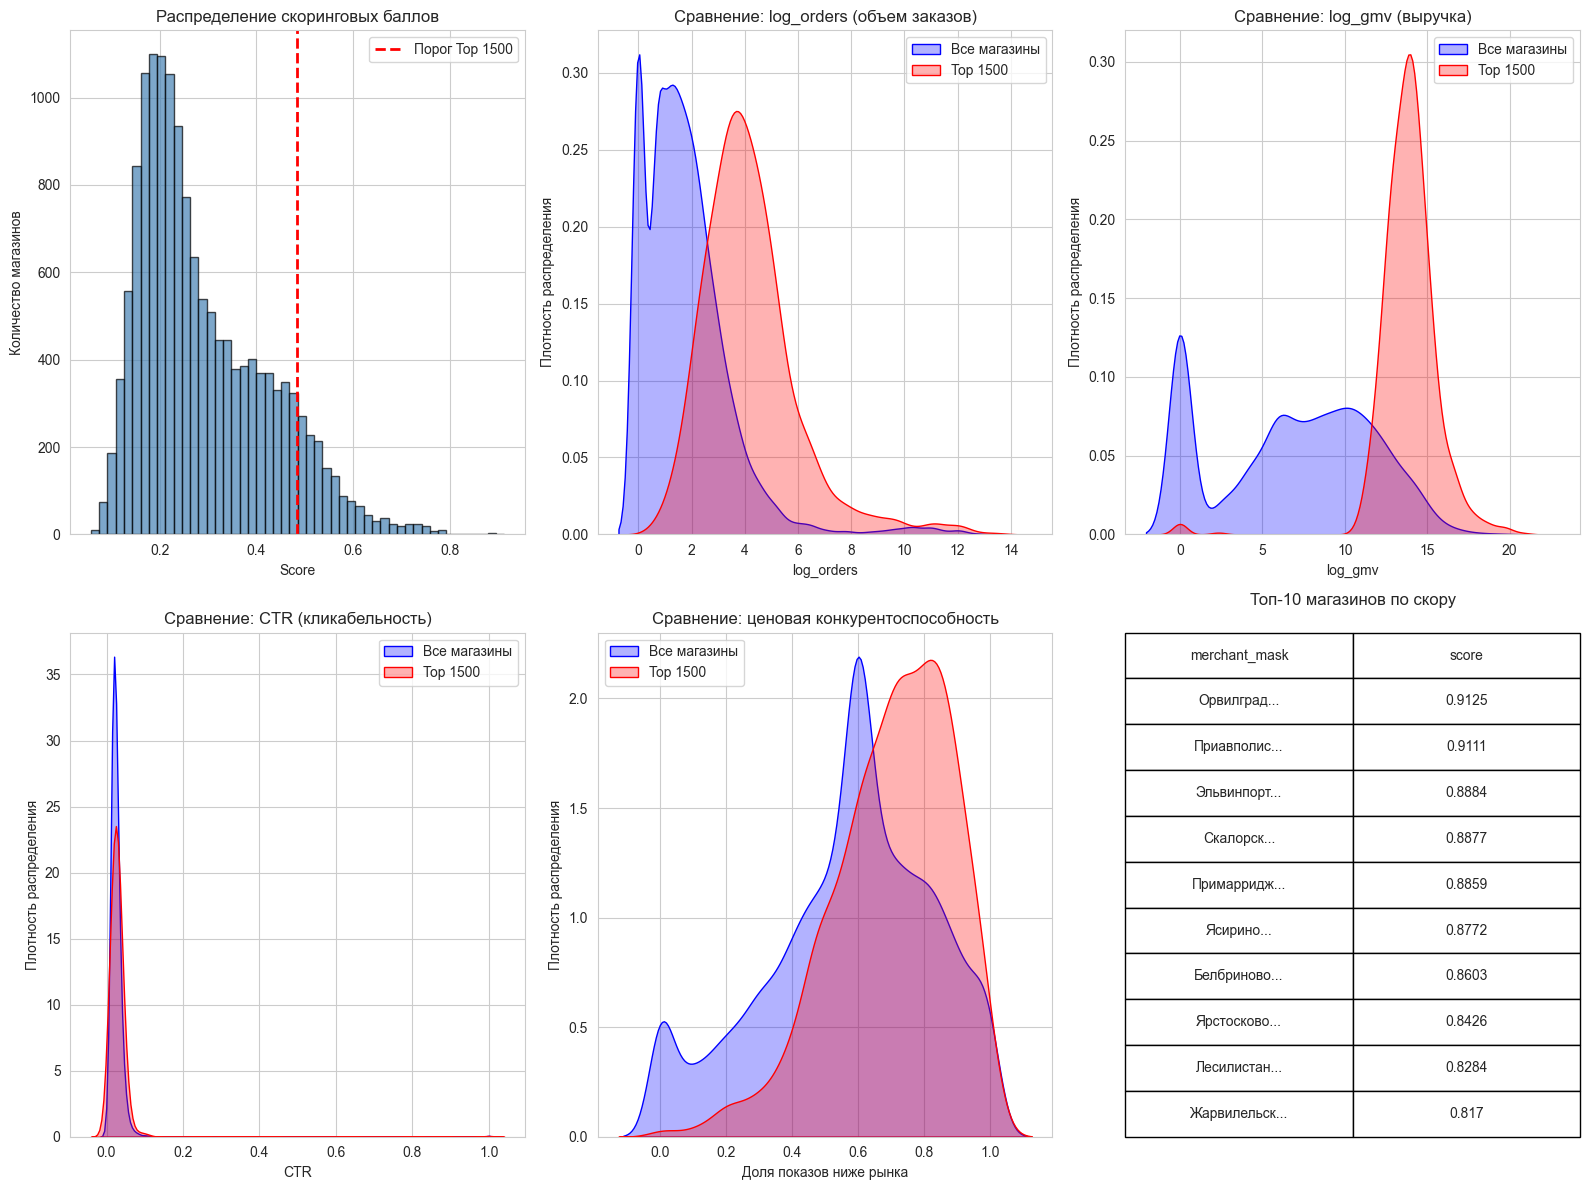

In [14]:
plt.figure(figsize=(16, 12))

# 1. Распределение скоров всех магазинов и порог для shortlist
plt.subplot(2, 3, 1)
plt.hist(df['score'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(shortlist['score'].min(), color='red', linestyle='--', linewidth=2, label=f'Порог Top {size}')
plt.title('Распределение скоринговых баллов')
plt.xlabel('Score')
plt.ylabel('Количество магазинов')
plt.legend()

# 2. Сравнение логарифма заказов
plt.subplot(2, 3, 2)
sns.kdeplot(df['log_orders'], label='Все магазины', color='blue', fill=True, alpha=0.3)
sns.kdeplot(shortlist['log_orders'], label=f'Top {size}', color='red', fill=True, alpha=0.3)
plt.title('Сравнение: log_orders (объем заказов)')
plt.xlabel('log_orders')
plt.ylabel('Плотность распределения')
plt.legend()

# 3. Сравнение логарифма выручки
plt.subplot(2, 3, 3)
sns.kdeplot(df['log_gmv'], label='Все магазины', color='blue', fill=True, alpha=0.3)
sns.kdeplot(shortlist['log_gmv'], label=f'Top {size}', color='red', fill=True, alpha=0.3)
plt.title('Сравнение: log_gmv (выручка)')
plt.xlabel('log_gmv')
plt.ylabel('Плотность распределения')
plt.legend()

# 4. Сравнение CTR
plt.subplot(2, 3, 4)
sns.kdeplot(df['CTR'], label='Все магазины', color='blue', fill=True, alpha=0.3)
sns.kdeplot(shortlist['CTR'], label=f'Top {size}', color='red', fill=True, alpha=0.3)
plt.title('Сравнение: CTR (кликабельность)')
plt.xlabel('CTR')
plt.ylabel('Плотность распределения')
plt.legend()

# 5. Сравнение ценовой конкурентоспособности
plt.subplot(2, 3, 5)
sns.kdeplot(df['price_competitiveness'], label='Все магазины', color='blue', fill=True, alpha=0.3)
sns.kdeplot(shortlist['price_competitiveness'], label=f'Top {size}', color='red', fill=True, alpha=0.3)
plt.title('Сравнение: ценовая конкурентоспособность')
plt.xlabel('Доля показов ниже рынка')
plt.ylabel('Плотность распределения')
plt.legend()

# 6. Топ-10 магазинов
plt.subplot(2, 3, 6)
plt.axis('off')
top10 = shortlist.head(10)[['merchant_mask', 'score']].round(4)
top10['merchant_mask'] = top10['merchant_mask'].str[:15] + '...'  # Обрезаем для красоты
table = plt.table(cellText=top10.values,
                  colLabels=top10.columns,
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
plt.title('Топ-10 магазинов по скору', pad=20)

plt.tight_layout()
plt.show()

Заключение:
 Графики наглядно демонстрируют эффективность отбора:

- Распределение рейтинга показывает, что порог отбора отсекает правый хвост распределения, выделяя магазины с наивысшими баллами. Распределение вполне себе адекватное.
- Анализ график показывает, что наша выборка из 1500 магазинов захватывает лучшие из показателей.

Для точности рейтинга посчитаем его корелляцию с другими факторами, например сегментом через Eta.




In [15]:
def eta_correlation(df, numeric_col, categorical_col):
    data = df[[numeric_col, categorical_col]].dropna()

    x = data[numeric_col]
    g = data[categorical_col]

    overall_mean = x.mean()

    group_stats = data.groupby(categorical_col)[numeric_col].agg(['mean', 'count'])
    ss_between = ((group_stats['count'] * (group_stats['mean'] - overall_mean) ** 2)).sum()
    ss_total = ((x - overall_mean) ** 2).sum()

    eta = np.sqrt(ss_between / ss_total) if ss_total != 0 else np.nan

    return eta

eta_value = eta_correlation(shortlist, 'score', 'segment_type')
print(f"Eta: {eta_value:.4f}")

if eta_value < 0.1:
    print("→ Связь очень слабая или отсутствует")
elif eta_value < 0.3:
    print("→ Слабая связь")
elif eta_value < 0.5:
    print("→ Умеренная связь")
elif eta_value < 0.7:
    print("→ Сильная связь")
else:
    print("→ Очень сильная связь")

Eta: 0.5953
→ Сильная связь


Мы видим подтверждение, что есть связь. Посмотрев в таблицу видим, что в топ 100 преобрладают компании их top100 и big, а ближе к концу small, nano, medium. Это еще одно докозательство того, что скоринговая модель работает исправно.